In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#import seaborn as sns
import cv2
import os
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121


In [10]:
def wafer_dilation_np(img):
    kernel = np.ones((2,2), np.uint8)
    return cv2.dilate(img, kernel)

def wafer_erosion_np(img):
    kernel = np.ones((2,2), np.uint8)
    return cv2.erode(img, kernel)

def wafer_sharpen_np(img):
    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
    return cv2.filter2D(img, -1, kernel)

def wafer_noise_np(img):
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255)
    return img.astype(np.uint8)

def wafer_random_erasing_np(img):
    h, w, _ = img.shape
    erase_h = int(h * 0.05)
    erase_w = int(w * 0.95)

    y = random.randint(0, h - erase_h)
    x = random.randint(0, w - erase_w)

    img[y:y+erase_h, x:x+erase_w, :] = 0
    return img
def random_wafer_augmentation(img):
    """
    img: numpy array (H, W, 3), uint8
    """
    if random.random() < 0.5:
        aug = random.choice([
            wafer_dilation_np,
            wafer_erosion_np,
            wafer_sharpen_np,
            wafer_noise_np,
            wafer_random_erasing_np
        ])
        img = aug(img)

    return img.astype(np.float32)



In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

# 訓練資料生成器，已包含增強
train_datagen = ImageDataGenerator(
    preprocessing_function=random_wafer_augmentation,
    rescale=1./255
)

# 驗證與測試資料生成器，只做 rescale，不做增強
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
val_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\val"
test_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\test"

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_set = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_set = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,   # ✅ 一定要是 tuple
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)




Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import random
import numpy as np
import cv2

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),


    Dense(train_set.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)
model.save("well_model.h5")


Epoch 1/5
3784/3784 [==============================] - ETA: 0s - loss: 0.4391 - accuracy: 0.8985

d:\anaconda\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3784/3784 [==============================] - 715s 187ms/step - loss: 0.4391 - accuracy: 0.8985 - val_loss: 0.3305 - val_accuracy: 0.9308 - lr: 0.0010
Epoch 2/5
3784/3784 [==============================] - 426s 113ms/step - loss: 0.2807 - accuracy: 0.9258 - val_loss: 0.2365 - val_accuracy: 0.9415 - lr: 0.0010
Epoch 3/5
3784/3784 [==============================] - 423s 112ms/step - loss: 0.2463 - accuracy: 0.9362 - val_loss: 0.1828 - val_accuracy: 0.9465 - lr: 0.0010
Epoch 4/5
3784/3784 [==============================] - 432s 114ms/step - loss: 0.2044 - accuracy: 0.9448 - val_loss: 0.1696 - val_accuracy: 0.9583 - lr: 0.0010
Epoch 5/5
3784/3784 [==============================] - 436s 115ms/step - loss: 0.1752 - accuracy: 0.9517 - val_loss: 0.1226 - val_accuracy: 0.9604 - lr: 0.0010


25946/25946 [==============================] - 76s 3ms/step


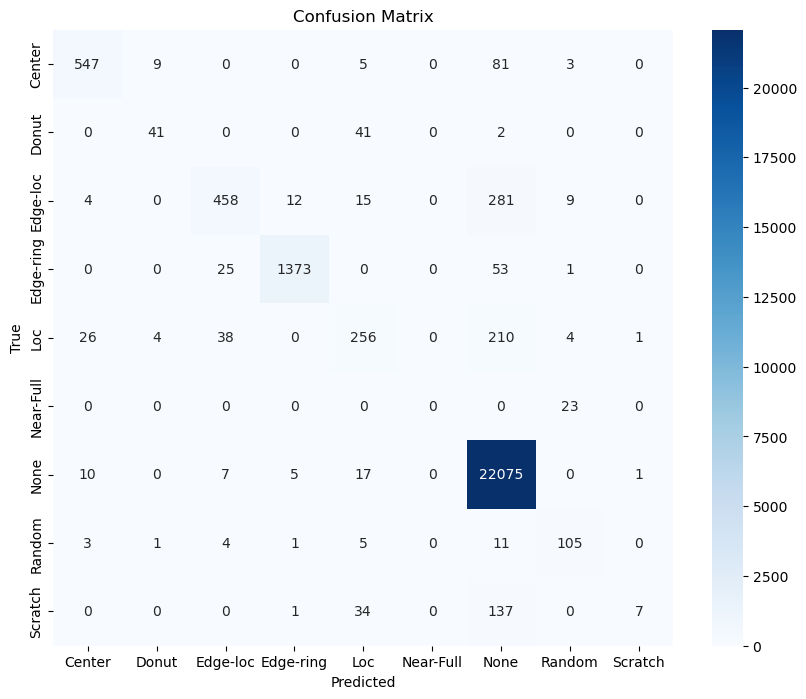

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = test_set.classes
y_pred_prob = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_set.class_indices.keys(),
            yticklabels=train_set.class_indices.keys(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [14]:
report = classification_report(y_true, y_pred, target_names=train_set.class_indices.keys())
print(report)


              precision    recall  f1-score   support

      Center       0.93      0.85      0.89       645
       Donut       0.75      0.49      0.59        84
    Edge-loc       0.86      0.59      0.70       779
   Edge-ring       0.99      0.95      0.97      1452
         Loc       0.69      0.47      0.56       539
   Near-Full       0.00      0.00      0.00        23
        None       0.97      1.00      0.98     22115
      Random       0.72      0.81      0.76       130
     Scratch       0.78      0.04      0.07       179

    accuracy                           0.96     25946
   macro avg       0.74      0.58      0.61     25946
weighted avg       0.95      0.96      0.95     25946



d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
